# Proyecto Innovacien — 2. Análisis: especies invasoras en zonas urbanas de Chile

**Curso:** Código y Programación · Samsung Innovation Campus Chile 2026 — Cohort 2

## Pregunta

> **¿Qué zonas urbanas de Chile se ven más afectadas por especies invasoras dañinas, y por cuáles?**

La obtención y limpieza de los datos está documentada en
[`01_obtencion_y_limpieza.ipynb`](01_obtencion_y_limpieza.ipynb). Aquí partimos de los
archivos ya procesados en `data/procesado/`.

**Métrica central:** *presión de invasión* = registros fotográficos de especies exóticas ÷
registros fotográficos totales de la zona. La proporción neutraliza el hecho de que unas
ciudades tienen muchos más observadores que otras.

In [1]:
import os
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paleta natural, la misma de la aplicación (core/theme.py)
VERDE, VERDE_OSC, VERDE_CLA = "#4A7C59", "#2F4F3E", "#8FB996"
TERRACOTA, OCRE, ARENA, CORTEZA = "#B4622F", "#C9A227", "#EFEADB", "#5C4A38"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": CORTEZA,
    "axes.labelcolor": CORTEZA,
    "text.color": "#2B2B26",
    "xtick.color": CORTEZA,
    "ytick.color": CORTEZA,
    "axes.grid": True,
    "grid.color": ARENA,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "figure.dpi": 110,
})

pd.set_option("display.width", 160)
print("Entorno listo")

Entorno listo


## Carga y unión de los datos procesados

In [2]:
P = Path("data/procesado")
catalogo = pd.read_csv(P / "catalogo_especies.csv")
zonas_especies = pd.read_csv(P / "zonas_especies.csv")
zonas_resumen = pd.read_csv(P / "zonas_resumen.csv")

# Unimos los conteos por zona con los atributos de cada especie
d = zonas_especies.merge(
    catalogo[["speciesKey", "binomio", "kingdom", "class", "family", "invasora", "habitat"]],
    on="speciesKey", how="left",
)

UMBRAL_MINIMO = 500  # registros totales mínimos para entrar en los rankings

print(f"Observaciones zona × especie : {len(d):,}")
print(f"Especies exóticas distintas  : {d.speciesKey.nunique()}")
print(f"  de ellas declaradas invasoras: {d[d.invasora].speciesKey.nunique()}")
print(f"Zonas urbanas                : {d.zona.nunique()}")
d.head()

Observaciones zona × especie : 2,543
Especies exóticas distintas  : 453
  de ellas declaradas invasoras: 148
Zonas urbanas                : 30


,zona,speciesKey,registros,binomio,kingdom,class,family,invasora,habitat
0,Gran Santiago,1340503,386,Bombus terrestris,Animalia,Insecta,Apidae,True,terrestrial
1,Gran Santiago,3117424,92,Bellis perennis,Plantae,Magnoliopsida,Asteraceae,True,terrestrial
2,Gran Santiago,3190653,86,Ailanthus altissima,Plantae,Magnoliopsida,Simaroubaceae,False,terrestrial
3,Gran Santiago,2979474,69,Acacia dealbata,Plantae,Magnoliopsida,Fabaceae,True,terrestrial
4,Gran Santiago,5371743,31,Anthriscus caucalis,Plantae,Magnoliopsida,Apiaceae,True,terrestrial


## Construcción de la tabla de presión por zona

In [3]:
# Agregado de exóticas por zona
agg_exo = d.groupby("zona").agg(
    reg_exoticas=("registros", "sum"),
    n_especies=("speciesKey", "nunique"),
)
# Agregado solo de las declaradas invasoras
agg_inv = d[d.invasora].groupby("zona").agg(
    reg_invasoras=("registros", "sum"),
    n_invasoras=("speciesKey", "nunique"),
)

zonas = (zonas_resumen
         .merge(agg_exo, on="zona", how="left")
         .merge(agg_inv, on="zona", how="left")
         .fillna({"reg_exoticas": 0, "n_especies": 0, "reg_invasoras": 0, "n_invasoras": 0}))

zonas["pct_exoticas"] = (zonas.reg_exoticas / zonas.registros_totales * 100).round(2)
zonas["pct_invasoras"] = (zonas.reg_invasoras / zonas.registros_totales * 100).round(2)
zonas["muestra_suficiente"] = zonas.registros_totales >= UMBRAL_MINIMO

ranking = zonas[zonas.muestra_suficiente].sort_values("pct_exoticas", ascending=False)

print(f"Zonas en el ranking: {len(ranking)} de {len(zonas)}")
ranking[["zona", "region", "registros_totales", "reg_exoticas",
         "pct_exoticas", "pct_invasoras", "n_especies", "n_invasoras"]].to_string(index=False)

Zonas en el ranking: 25 de 30


"           zona             region  registros_totales  reg_exoticas  pct_exoticas  pct_invasoras  n_especies  n_invasoras\n      Melipilla      Metropolitana                822           297         36.13          13.02         127           48\n        Chillan              Nuble               1523           466         30.60          14.71         105           36\n          Talca              Maule               1639           409         24.95           9.21          97           40\n       Rancagua          O'Higgins               1252           278         22.20           7.91          94           33\n  Gran Santiago      Metropolitana              48832          6607         13.53           6.63         266           94\n       Quillota         Valparaiso                881           117         13.28           5.68          66           30\n         Curico              Maule                935           117         12.51           4.60          73           27\n      Coyhaique

---
# Indicadores principales

In [4]:
tot_reg = zonas.registros_totales.sum()
tot_exo = zonas.reg_exoticas.sum()
tot_inv = zonas.reg_invasoras.sum()

# Hay empates en número de zonas (abejorro y paloma están en 26 cada uno),
# así que desempatamos por total de registros.
alcance = (d.groupby("binomio")
           .agg(zonas=("zona", "nunique"), registros=("registros", "sum"))
           .sort_values(["zonas", "registros"], ascending=False))
mas_extendida = alcance.index[0]
n_zonas_extendida = alcance.iloc[0].zonas
empatadas = (alcance.zonas == n_zonas_extendida).sum()

kpis = {
    "Zonas urbanas analizadas": f"{len(zonas)}",
    "Registros fotográficos revisados": f"{tot_reg:,}",
    "Especies exóticas detectadas en ciudades": f"{d.speciesKey.nunique()}",
    "Especies invasoras declaradas en ciudades": f"{d[d.invasora].speciesKey.nunique()}",
    "% de registros urbanos que son exóticos": f"{tot_exo / tot_reg * 100:.1f}%",
    "% que son de invasoras declaradas": f"{tot_inv / tot_reg * 100:.1f}%",
    "Zona con mayor presión": f"{ranking.iloc[0].zona} ({ranking.iloc[0].pct_exoticas:.1f}%)",
    "Zona con menor presión": f"{ranking.iloc[-1].zona} ({ranking.iloc[-1].pct_exoticas:.1f}%)",
    "Especie más extendida": f"{mas_extendida} ({n_zonas_extendida} de {len(zonas)} zonas)",
}

for k, v in kpis.items():
    print(f"  {k:44} {v}")

print(f"\nNota: {empatadas} especies empatan en {n_zonas_extendida} zonas. "
      f"Desempatamos por total de registros:")
print(alcance.head(4).to_string())

  Zonas urbanas analizadas                     30
  Registros fotográficos revisados             175,379
  Especies exóticas detectadas en ciudades     453
  Especies invasoras declaradas en ciudades    148
  % de registros urbanos que son exóticos      10.2%
  % que son de invasoras declaradas            4.7%
  Zona con mayor presión                       Melipilla (36.1%)
  Zona con menor presión                       Arica (0.6%)
  Especie más extendida                        Bombus terrestris (26 de 30 zonas)

Nota: 2 especies empatan en 26 zonas. Desempatamos por total de registros:
                   zonas  registros
binomio                            
Bombus terrestris     26       1020
Columba livia         26        750
Passer domesticus     25        496
Harmonia axyridis     22        783


---
# Visualización 1 — Ranking de zonas urbanas por presión de invasión

La pregunta pide *qué zonas*. Esta es la respuesta directa. La barra completa es el total
de registros exóticos; la porción oscura es la parte que corresponde a especies
**declaradas invasoras**.

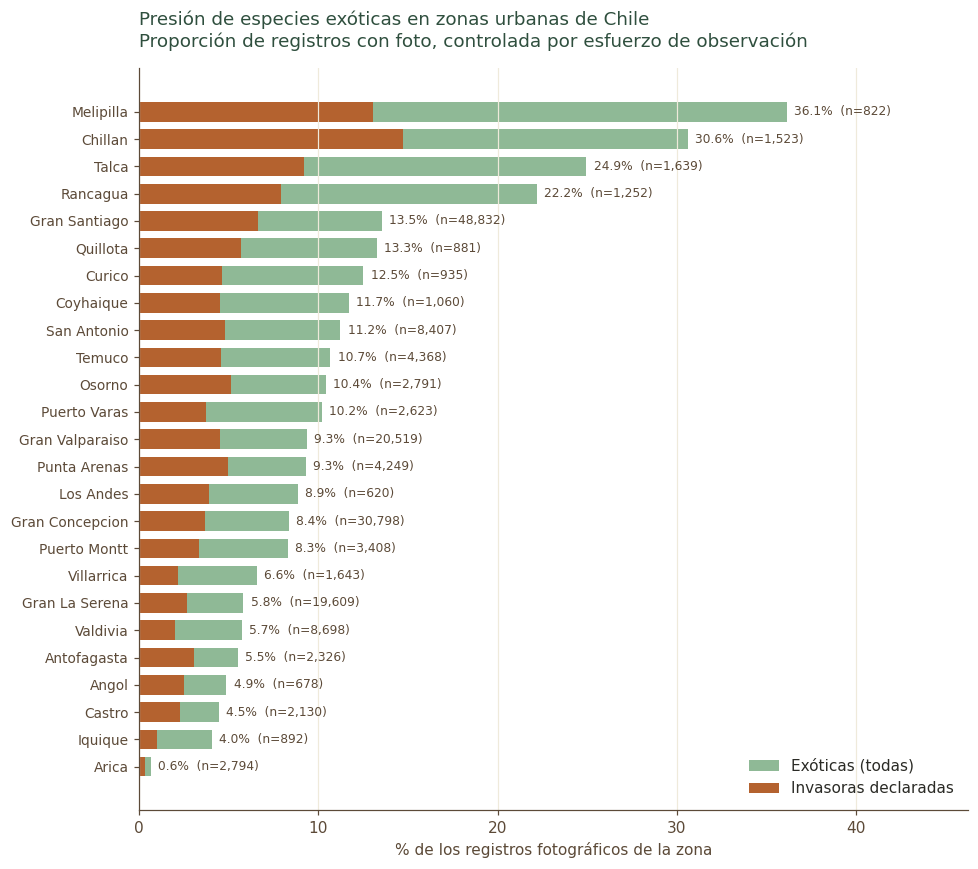

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))
r = ranking.sort_values("pct_exoticas")
y = np.arange(len(r))

ax.barh(y, r.pct_exoticas, color=VERDE_CLA, label="Exóticas (todas)", height=0.72)
ax.barh(y, r.pct_invasoras, color=TERRACOTA, label="Invasoras declaradas", height=0.72)

ax.set_yticks(y)
ax.set_yticklabels([f"{z}" for z in r.zona], fontsize=9)
ax.set_xlabel("% de los registros fotográficos de la zona")
ax.set_title("Presión de especies exóticas en zonas urbanas de Chile\n"
             "Proporción de registros con foto, controlada por esfuerzo de observación",
             fontsize=12, color=VERDE_OSC, pad=14, loc="left")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)

for yi, (pe, n) in enumerate(zip(r.pct_exoticas, r.registros_totales)):
    ax.text(pe + 0.4, yi, f"{pe:.1f}%  (n={n:,})", va="center", fontsize=8, color=CORTEZA)

ax.set_xlim(0, r.pct_exoticas.max() * 1.28)
plt.tight_layout()
plt.show()

**Lo que muestra.** Las ciudades del **Valle Central** encabezan el ranking: Melipilla,
Chillán, Talca y Rancagua superan todas el 22% de registros exóticos. En el otro extremo,
Arica queda por debajo del 1% — casi cincuenta veces menos.

Dos advertencias honestas sobre este gráfico:

- **Melipilla tiene la muestra más chica** de las que pasan el umbral (822 registros). Su
  primer lugar es real pero menos robusto que el de Chillán o Talca. El patrón regional
  se sostiene igual, porque son cuatro ciudades de la misma zona, no una.
- Las proporciones probablemente están **infladas** por el sesgo de fotografiabilidad que
  documentamos en el notebook 1. Lo comparable es el orden, no el valor absoluto.

---
# Visualización 2 — El gradiente latitudinal

El ranking anterior sugiere un patrón geográfico. Lo verificamos poniendo la latitud en un
eje: si el patrón es real, debería verse una curva, no una nube.

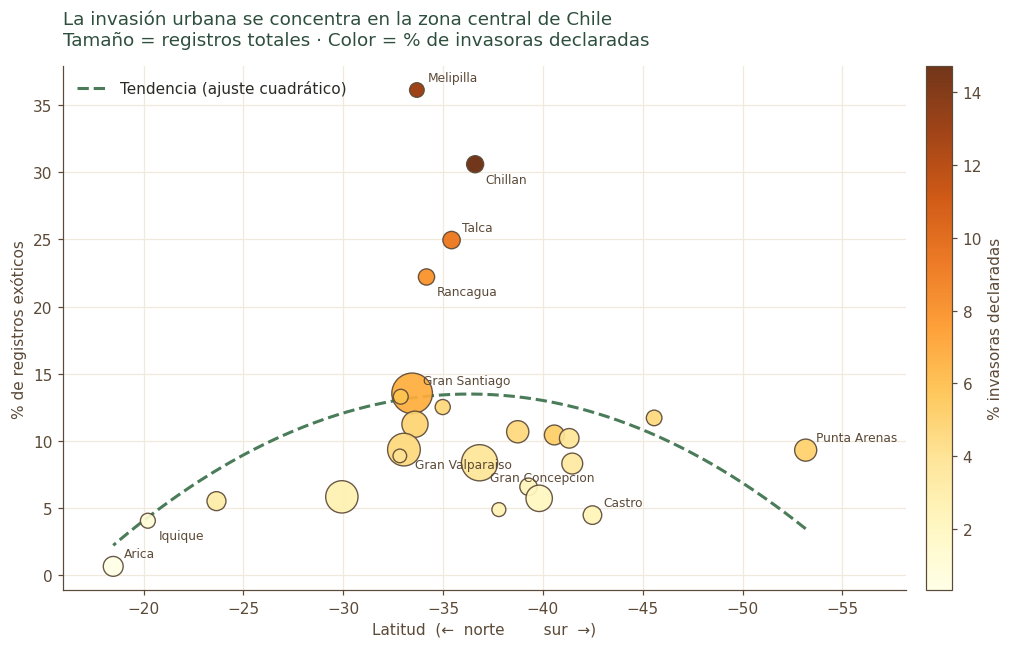

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(ranking.lat, ranking.pct_exoticas,
                s=np.sqrt(ranking.registros_totales) * 3.2,
                c=ranking.pct_invasoras, cmap="YlOrBr",
                edgecolor=CORTEZA, linewidth=0.9, alpha=0.92, zorder=3)

# Tendencia cuadrática: el fenómeno no es lineal, tiene un máximo en la zona central
coef = np.polyfit(ranking.lat, ranking.pct_exoticas, 2)
xs = np.linspace(ranking.lat.min(), ranking.lat.max(), 200)
ax.plot(xs, np.polyval(coef, xs), color=VERDE, lw=2, ls="--", zorder=2,
        label="Tendencia (ajuste cuadrático)")

# Etiquetamos solo un conjunto curado, para que el gráfico se pueda leer:
# las cuatro de mayor presión, las tres metrópolis y los extremos del país.
DESTACAR = ["Melipilla", "Chillan", "Talca", "Rancagua", "Gran Santiago",
            "Gran Concepcion", "Gran Valparaiso", "Arica", "Iquique",
            "Punta Arenas", "Castro"]
for k, (_, f) in enumerate(ranking[ranking.zona.isin(DESTACAR)].iterrows()):
    dx, dy = (7, 6) if k % 2 == 0 else (7, -12)
    ax.annotate(f.zona, (f.lat, f.pct_exoticas), fontsize=8, color=CORTEZA,
                xytext=(dx, dy), textcoords="offset points")

ax.set_xlabel("Latitud  (←  norte        sur  →)")
ax.set_ylabel("% de registros exóticos")
ax.set_title("La invasión urbana se concentra en la zona central de Chile\n"
             "Tamaño = registros totales · Color = % de invasoras declaradas",
             fontsize=12, color=VERDE_OSC, pad=14, loc="left")
# Invertimos el eje (norte a la izquierda) dejando margen para las etiquetas
ax.set_xlim(ranking.lat.max() + 2.5, ranking.lat.min() - 5)
ax.legend(frameon=False, loc="upper left")
plt.colorbar(sc, ax=ax, label="% invasoras declaradas", pad=0.02)
plt.tight_layout()
plt.show()

**Lo que muestra.** El patrón es claro y tiene explicación ecológica: el máximo está entre
los 33° y 37° de latitud sur — la zona de **clima mediterráneo** de Chile.

Casi todas las especies exóticas de Chile llegaron desde Europa, y el centro del país tiene
el clima al que ya estaban adaptadas: inviernos lluviosos y templados, veranos secos. Es la
misma razón por la que ahí funciona la vid y el olivo. Hacia el norte el desierto las
bloquea (Arica, Iquique), y hacia el sur el clima frío y lluvioso las frena
(Punta Arenas, Castro).

---
# Visualización 3 — Mapa: dónde están las zonas más afectadas

Los mismos datos sobre la geometría real del país.

/var/folders/7x/8s0wzvpd6yz7rjgtg9jxgzj80000gn/T/ipykernel_15583/4085099209.py:10: UserWarning: You passed a edgecolor/edgecolors ('#5C4A38') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sin_m.lon, sin_m.lat, s=30, facecolor="white",


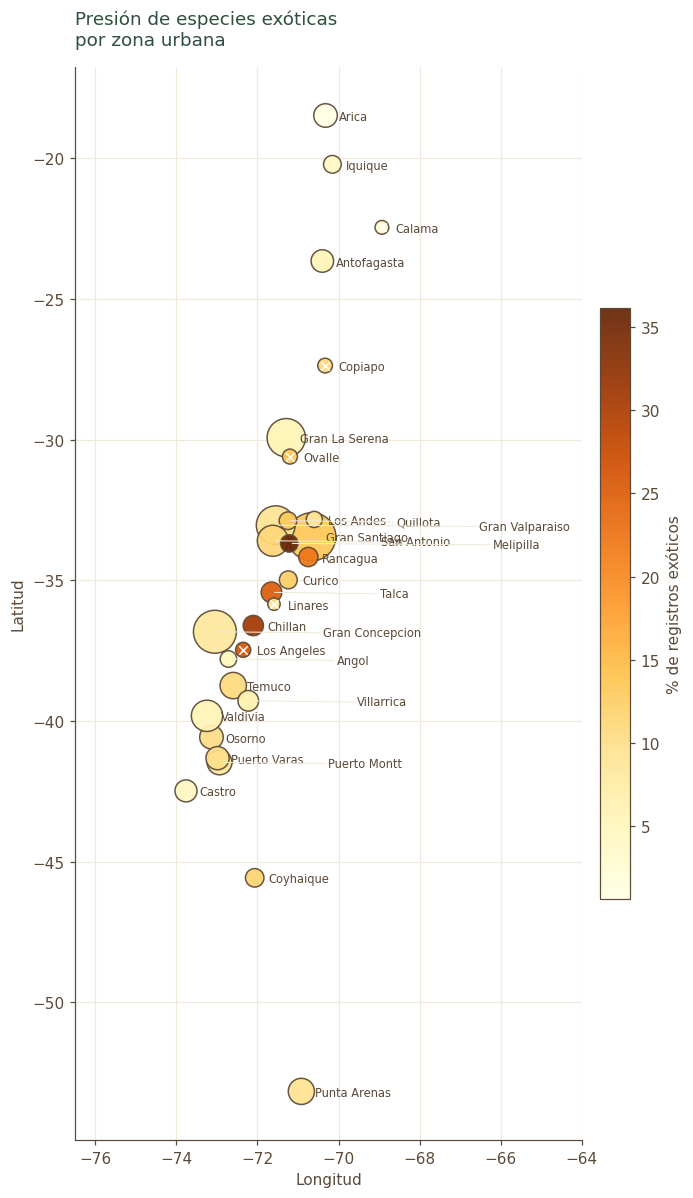

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 11))

sc = ax.scatter(zonas.lon, zonas.lat,
                s=np.sqrt(zonas.registros_totales.clip(lower=1)) * 4.5,
                c=zonas.pct_exoticas, cmap="YlOrBr",
                edgecolor=CORTEZA, linewidth=1.0, alpha=0.93, zorder=3)

# Las zonas sin muestra suficiente se marcan distinto
sin_m = zonas[~zonas.muestra_suficiente]
ax.scatter(sin_m.lon, sin_m.lat, s=30, facecolor="white",
           edgecolor=CORTEZA, linewidth=1.0, zorder=4, marker="x")

# Chile central concentra muchas ciudades muy cercanas: si etiquetamos todas en
# la misma posición se pisan. Escalonamos hacia la derecha cuando la anterior
# está a menos de medio grado de latitud.
usadas = []
for _, f in zonas.sort_values("lat", ascending=False).iterrows():
    nivel = 0
    while any(abs(f.lat - la) < 0.55 and n == nivel for la, n in usadas):
        nivel += 1
    usadas.append((f.lat, nivel))
    ax.annotate(f.zona, (f.lon, f.lat), fontsize=7.5, color=CORTEZA,
                xytext=(9 + nivel * 62, -3), textcoords="offset points",
                arrowprops=dict(arrowstyle="-", color=ARENA, lw=0.7,
                                shrinkA=0, shrinkB=2) if nivel else None)

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Presión de especies exóticas\npor zona urbana",
             fontsize=12, color=VERDE_OSC, pad=14, loc="left")
ax.set_xlim(-76.5, -64.0)
plt.colorbar(sc, ax=ax, label="% de registros exóticos", shrink=0.55, pad=0.03)
plt.tight_layout()
plt.show()

---
# Visualización 4 — ¿Por cuáles especies?

La segunda mitad de la pregunta. Ordenamos las especies exóticas por total de registros
fotográficos en zonas urbanas, distinguiendo las que están **declaradas invasoras** en el
registro oficial de las que solo figuran como exóticas.

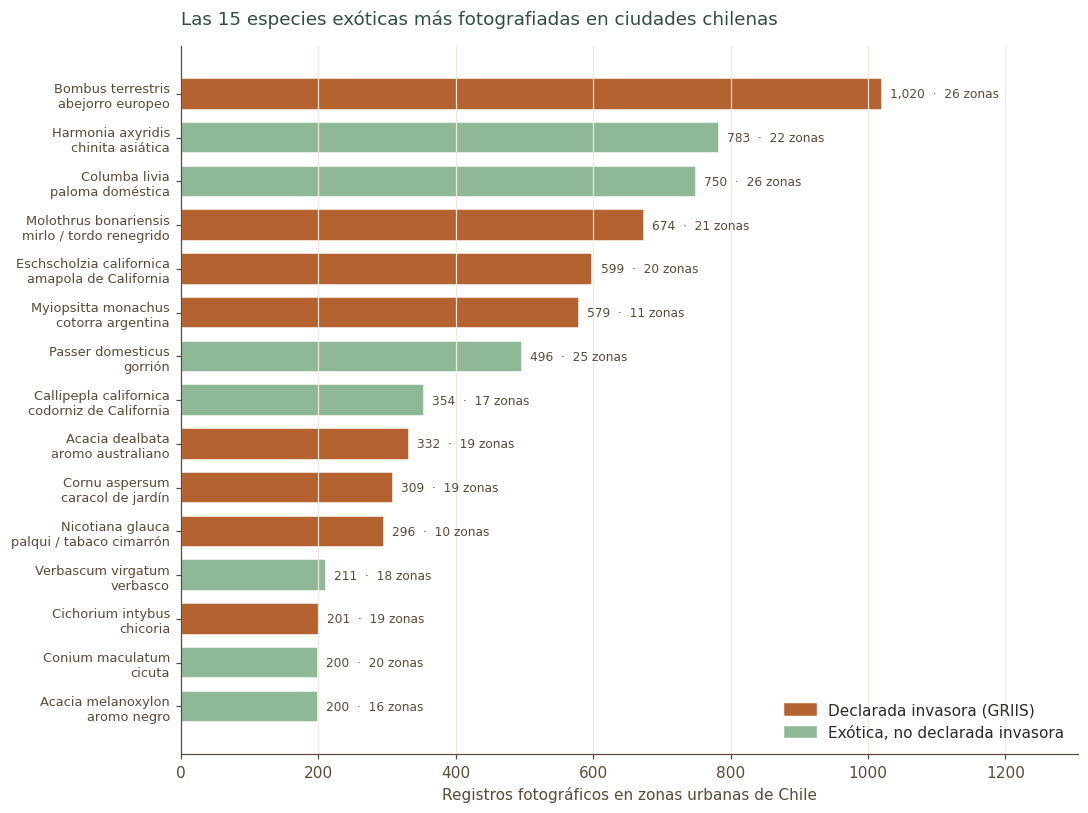

In [8]:
top = (d.groupby(["binomio", "class", "invasora"])
       .agg(registros=("registros", "sum"), zonas=("zona", "nunique"))
       .reset_index()
       .sort_values("registros", ascending=False)
       .head(15))

# Nombres comunes, para que el gráfico se lea sin saber latín
COMUNES = {
    "Bombus terrestris": "abejorro europeo",
    "Harmonia axyridis": "chinita asiática",
    "Columba livia": "paloma doméstica",
    "Molothrus bonariensis": "mirlo / tordo renegrido",
    "Eschscholzia californica": "amapola de California",
    "Myiopsitta monachus": "cotorra argentina",
    "Passer domesticus": "gorrión",
    "Callipepla californica": "codorniz de California",
    "Acacia dealbata": "aromo australiano",
    "Cornu aspersum": "caracol de jardín",
    "Nicotiana glauca": "palqui / tabaco cimarrón",
    "Verbascum virgatum": "verbasco",
    "Cichorium intybus": "chicoria",
    "Acacia melanoxylon": "aromo negro",
    "Conium maculatum": "cicuta",
    "Oryctolagus cuniculus": "conejo europeo",
    "Ulex europaeus": "espinillo",
    "Taraxacum officinale": "diente de león",
    "Vespula germanica": "avispa chaqueta amarilla",
    "Rubus ulmifolius": "zarzamora",
    "Rattus rattus": "rata negra",
    "Rattus norvegicus": "rata gris",
    "Mus musculus": "ratón doméstico",
    "Xenopus laevis": "rana africana",
    "Linepithema humile": "hormiga argentina",
    "Apis mellifera": "abeja melífera",
    "Sus scrofa": "jabalí",
    "Castor canadensis": "castor americano",
    "Foeniculum vulgare": "hinojo",
    "Plantago lanceolata": "llantén",
    "Trifolium repens": "trébol blanco",
    "Genista monspessulana": "retamilla",
    "Pinus radiata": "pino insigne",
    "Salix babylonica": "sauce llorón",
    "Ficus carica": "higuera",
    "Ailanthus altissima": "árbol del cielo",
    "Fumaria capreolata": "flor de la culebra",
    "Melilotus indicus": "trébol de olor",
    "Silybum marianum": "cardo mariano",
    "Galega officinalis": "galega",
    "Erodium cicutarium": "alfilerillo",
    "Medicago polymorpha": "hualputra",
    "Bubulcus ibis": "garza boyera",
    "Sturnus vulgaris": "estornino",
    "Anas platyrhynchos": "pato doméstico",
    "Lolium perenne": "ballica",
    "Avena barbata": "teatina",
    "Brassica rapa": "yuyo",
    "Rosa rubiginosa": "rosa mosqueta",
}

fig, ax = plt.subplots(figsize=(10, 7.5))
t = top.sort_values("registros")
y = np.arange(len(t))
colores = [TERRACOTA if inv else VERDE_CLA for inv in t.invasora]

ax.barh(y, t.registros, color=colores, height=0.72, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels([f"{b}\n{COMUNES.get(b, '')}" for b in t.binomio], fontsize=8.5)
ax.set_xlabel("Registros fotográficos en zonas urbanas de Chile")
ax.set_title("Las 15 especies exóticas más fotografiadas en ciudades chilenas",
             fontsize=12, color=VERDE_OSC, pad=14, loc="left")

for yi, (n, z) in enumerate(zip(t.registros, t.zonas)):
    ax.text(n + 12, yi, f"{n:,}  ·  {z} zonas", va="center", fontsize=8, color=CORTEZA)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=TERRACOTA, label="Declarada invasora (GRIIS)"),
                   Patch(color=VERDE_CLA, label="Exótica, no declarada invasora")],
          loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, t.registros.max() * 1.28)
plt.tight_layout()
plt.show()

**Lo que muestra.** El primer lugar es el **abejorro europeo** (*Bombus terrestris*), con más
de mil registros y presencia en 26 de las 30 zonas. No es una curiosidad: se introdujo para
polinizar cultivos y hoy está desplazando al abejorro nativo chileno (*Bombus dahlbomii*),
el más grande del mundo, que retrocede a medida que el europeo avanza.

Y aquí aparece el hallazgo incómodo: **de las 20 especies exóticas más fotografiadas en
ciudades, solo la mitad está declarada invasora.** La paloma, el gorrión, la chinita
asiática y la codorniz de California — todas dominantes en el paisaje urbano — figuran en
el registro oficial como exóticas sin evaluar.

In [9]:
t20 = (d.groupby(["binomio", "invasora"]).registros.sum().reset_index()
       .sort_values("registros", ascending=False).head(20))
no_decl = t20[~t20.invasora]

print(f"De las 20 exóticas más fotografiadas en ciudades:")
print(f"  declaradas invasoras     : {int(t20.invasora.sum())}")
print(f"  solo exóticas (sin evaluar): {len(no_decl)}")
print(f"\nLas no declaradas aportan {no_decl.registros.sum():,} de {t20.registros.sum():,} "
      f"registros ({no_decl.registros.sum()/t20.registros.sum()*100:.0f}% del total).")
print("\nLas más presentes sin estar declaradas invasoras:")
for _, f in no_decl.head(6).iterrows():
    print(f"  {f.binomio:26} {f.registros:>5,} registros   ({COMUNES.get(f.binomio,'')})")

De las 20 exóticas más fotografiadas en ciudades:
  declaradas invasoras     : 10
  solo exóticas (sin evaluar): 10

Las no declaradas aportan 3,530 de 7,905 registros (45% del total).

Las más presentes sin estar declaradas invasoras:
  Harmonia axyridis            783 registros   (chinita asiática)
  Columba livia                750 registros   (paloma doméstica)
  Passer domesticus            496 registros   (gorrión)
  Callipepla californica       354 registros   (codorniz de California)
  Verbascum virgatum           211 registros   (verbasco)
  Acacia melanoxylon           200 registros   (aromo negro)


---
# Visualización 5 — Qué especie manda en cada ciudad

Un ranking nacional esconde que cada ciudad tiene su propia especie dominante. El mapa de
calor muestra la distribución de las principales invasoras declaradas por zona.

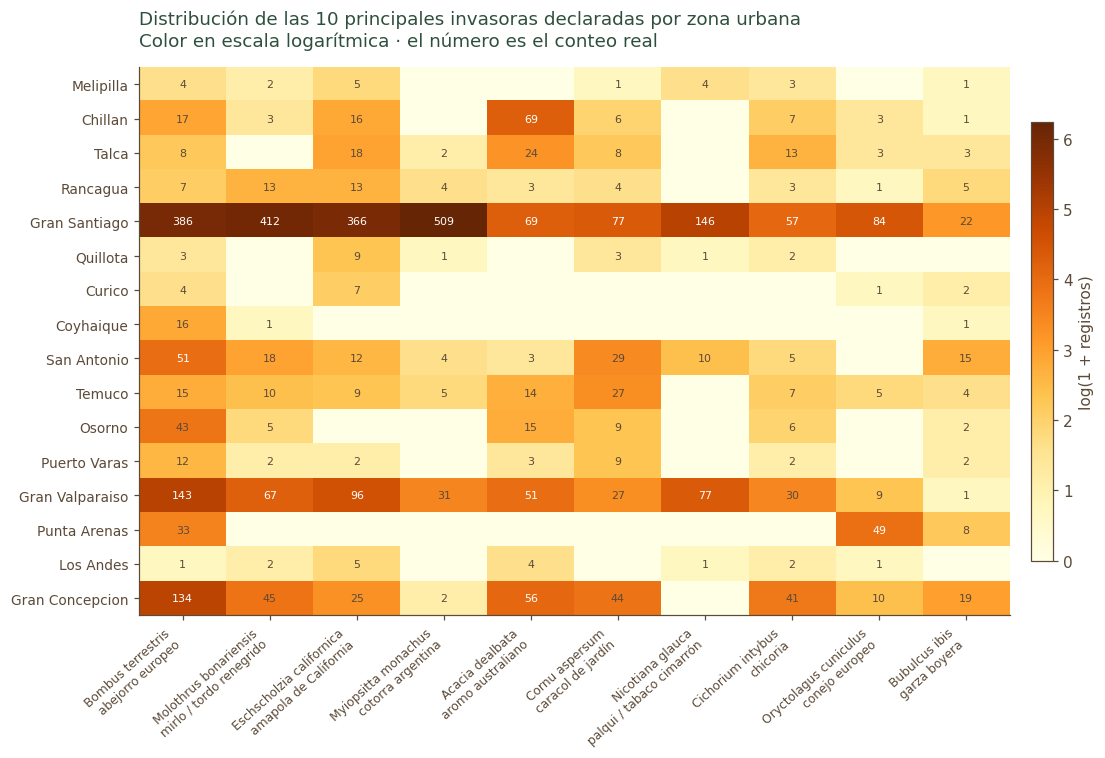

In [10]:
inv = d[d.invasora]
top_inv = (inv.groupby("binomio").registros.sum()
           .sort_values(ascending=False).head(10).index.tolist())
zonas_ord = ranking.zona.tolist()[:16]

pivot = (inv[inv.binomio.isin(top_inv) & inv.zona.isin(zonas_ord)]
         .pivot_table(index="zona", columns="binomio", values="registros",
                      aggfunc="sum", fill_value=0)
         .reindex(index=zonas_ord, columns=top_inv, fill_value=0))

fig, ax = plt.subplots(figsize=(11, 7))
# Escala logarítmica: Santiago aplasta al resto en valores absolutos
im = ax.imshow(np.log1p(pivot.values), cmap="YlOrBr", aspect="auto")

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([f"{c}\n{COMUNES.get(c,'')}" for c in pivot.columns],
                   rotation=42, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title("Distribución de las 10 principales invasoras declaradas por zona urbana\n"
             "Color en escala logarítmica · el número es el conteo real",
             fontsize=12, color=VERDE_OSC, pad=14, loc="left")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = int(pivot.values[i, j])
        if v > 0:
            ax.text(j, i, v, ha="center", va="center", fontsize=7.2,
                    color="white" if np.log1p(v) > np.log1p(pivot.values.max()) * 0.62 else CORTEZA)

ax.grid(visible=False)
plt.colorbar(im, ax=ax, label="log(1 + registros)", pad=0.02, shrink=0.8)
plt.tight_layout()
plt.show()

In [11]:
# La especie dominante de cada zona
dom = inv.loc[inv.groupby("zona").registros.idxmax()][["zona", "binomio", "registros"]]
dom = dom.merge(zonas[["zona", "registros_totales", "muestra_suficiente"]], on="zona")
dom = dom[dom.muestra_suficiente].sort_values("registros", ascending=False)
dom["nombre_comun"] = dom.binomio.map(COMUNES).fillna("—")

print("Invasora declarada dominante en cada zona urbana:\n")
print(dom[["zona", "binomio", "nombre_comun", "registros"]].to_string(index=False))
print()
print("Especies que dominan al menos una zona:")
print(dom.binomio.value_counts().to_string())

Invasora declarada dominante en cada zona urbana:

           zona                  binomio            nombre_comun  registros
  Gran Santiago      Myiopsitta monachus       cotorra argentina        509
Gran Valparaiso        Bombus terrestris        abejorro europeo        143
Gran Concepcion        Bombus terrestris        abejorro europeo        134
 Gran La Serena        Bombus terrestris        abejorro europeo         81
        Chillan          Acacia dealbata       aromo australiano         69
    San Antonio        Bombus terrestris        abejorro europeo         51
   Punta Arenas    Oryctolagus cuniculus          conejo europeo         49
         Osorno        Bombus terrestris        abejorro europeo         43
         Temuco           Cornu aspersum       caracol de jardín         27
          Talca          Acacia dealbata       aromo australiano         24
       Valdivia        Bombus terrestris        abejorro europeo         22
    Antofagasta    Molothrus bonarien

**Lo que muestra.** El **abejorro europeo domina la mayoría de las ciudades** del país — es
la invasora urbana más generalizada de Chile.

La excepción es Santiago, y es espectacular: la **cotorra argentina** (*Myiopsitta monachus*)
tiene 509 de sus 579 registros nacionales dentro del Gran Santiago. **El 88% de la
población fotografiada de esta especie está en una sola ciudad.** Es un caso de invasión
puramente metropolitana: llegó como mascota, se escapó, y armó colonias en los parques y
el arbolado urbano de la capital.

Punta Arenas también rompe el patrón, con el **conejo europeo** como dominante — coherente
con una ciudad rodeada de estepa patagónica.

---
# Visualización 6 — Qué tipo de organismo invade la ciudad

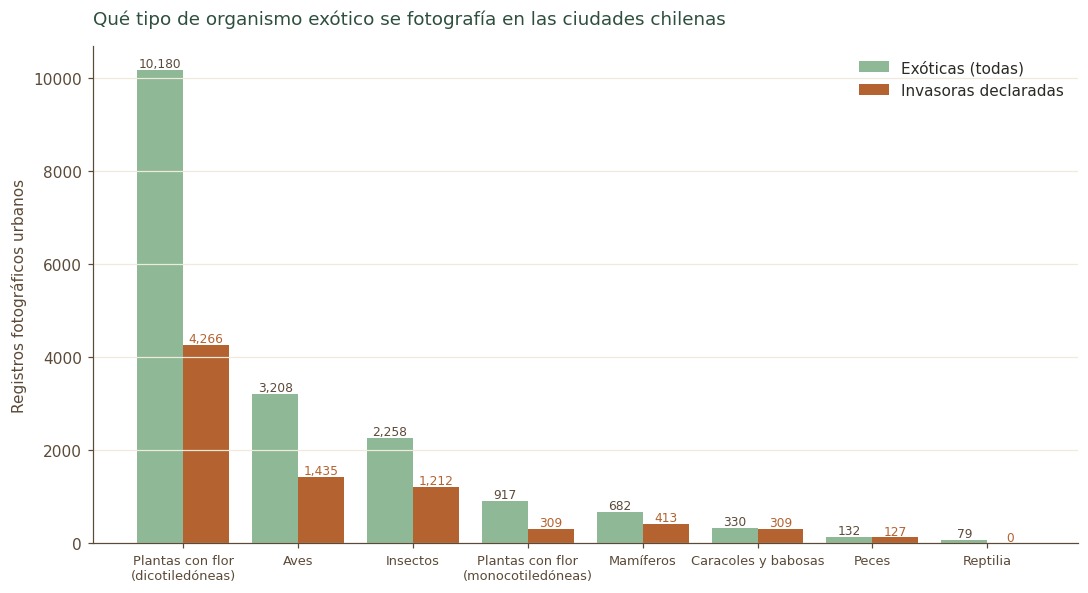

In [12]:
comp_exo = d.groupby("class").registros.sum().sort_values(ascending=False).head(8)
comp_inv = inv.groupby("class").registros.sum().reindex(comp_exo.index).fillna(0)

ETIQ = {
    "Magnoliopsida": "Plantas con flor\n(dicotiledóneas)",
    "Aves": "Aves",
    "Insecta": "Insectos",
    "Liliopsida": "Plantas con flor\n(monocotiledóneas)",
    "Mammalia": "Mamíferos",
    "Gastropoda": "Caracoles y babosas",
    "Actinopterygii": "Peces",
    "Pinopsida": "Coníferas",
}

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(comp_exo))
ax.bar(x - 0.2, comp_exo.values, width=0.4, color=VERDE_CLA, label="Exóticas (todas)")
ax.bar(x + 0.2, comp_inv.values, width=0.4, color=TERRACOTA, label="Invasoras declaradas")

ax.set_xticks(x)
ax.set_xticklabels([ETIQ.get(c, c) for c in comp_exo.index], fontsize=8.5)
ax.set_ylabel("Registros fotográficos urbanos")
ax.set_title("Qué tipo de organismo exótico se fotografía en las ciudades chilenas",
             fontsize=12, color=VERDE_OSC, pad=14, loc="left")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)

for xi, (a, b) in enumerate(zip(comp_exo.values, comp_inv.values)):
    ax.text(xi - 0.2, a + 60, f"{int(a):,}", ha="center", fontsize=8, color=CORTEZA)
    ax.text(xi + 0.2, b + 60, f"{int(b):,}", ha="center", fontsize=8, color=TERRACOTA)

plt.tight_layout()
plt.show()

In [13]:
# ¿Qué proporción de los registros exóticos de cada grupo corresponde a
# especies que YA están declaradas invasoras?
tasa = pd.DataFrame({"exoticas": comp_exo, "invasoras": comp_inv})
tasa["% declarado"] = (tasa.invasoras / tasa.exoticas * 100).round(1)
tasa.index = [ETIQ.get(c, c).replace("\n", " ") for c in tasa.index]
print("Cobertura del registro oficial por grupo taxonómico:\n")
print(tasa.sort_values("% declarado", ascending=False).to_string())

Cobertura del registro oficial por grupo taxonómico:

                                     exoticas  invasoras  % declarado
Peces                                     132      127.0         96.2
Caracoles y babosas                       330      309.0         93.6
Mamíferos                                 682      413.0         60.6
Insectos                                 2258     1212.0         53.7
Aves                                     3208     1435.0         44.7
Plantas con flor (dicotiledóneas)       10180     4266.0         41.9
Plantas con flor (monocotiledóneas)       917      309.0         33.7
Reptilia                                   79        0.0          0.0


**Lo que muestra.** Las plantas dominan por volumen: 10.180 registros urbanos, tres veces
más que las aves. Pero la tabla de arriba muestra el patrón interesante, y **no es el que
esperábamos**: los grupos con mejor cobertura del registro oficial son los **peces (96%)**,
los **caracoles (94%)** y los **mamíferos (61%)**, mientras que las **plantas con flor se
quedan en 42%** — casi lo mismo que las aves (45%).

Es decir: los animales que se pescan, se comen o hacen daño visible a la agricultura están
bien evaluados. Las plantas exóticas urbanas, que son la mayoría absoluta de lo que la gente
fotografía en la ciudad, son justamente las peor cubiertas por el registro oficial. Y
`Reptilia` aparece con 79 registros exóticos y **ninguna** especie declarada invasora.

---
# Hallazgo principal

*(explicación en lenguaje no técnico — requisito de la pauta)*

## La invasión biológica en Chile no está en los bosques lejanos: está en las plazas del Valle Central

Analizamos **más de 170 mil fotografías** de plantas y animales tomadas por personas
comunes en 30 ciudades de Chile, y las cruzamos con el registro oficial de especies
invasoras del país. Encontramos tres cosas.

**1. Hay una franja del país claramente más invadida que el resto.**
En Melipilla, Chillán, Talca y Rancagua, **entre el 22% y el 36% de las fotos de naturaleza
corresponde a una especie que no es chilena** — hasta 1 de cada 3. En Arica es el 0,6%:
menos de 1 de cada 100. La razón es el clima: casi todas estas especies llegaron de Europa, y el centro
de Chile tiene el mismo clima mediterráneo del que vinieron. El desierto del norte y el
frío del sur funcionan como barreras naturales.

**2. Hay una especie que está en casi todas las ciudades del país.**
El **abejorro europeo** aparece en 26 de las 30 zonas analizadas. Se trajo a propósito para
polinizar cultivos, y hoy está desplazando al abejorro nativo chileno, que es el más grande
del mundo. En Santiago la protagonista es otra: la **cotorra argentina**, con el 88% de sus
registros nacionales concentrados en la capital. Llegó como mascota, se escapó y colonizó
el arbolado urbano.

**3. El registro oficial mira el campo, no la ciudad.**
Este es el hallazgo que más nos sorprendió. De las 20 especies exóticas más fotografiadas
en ciudades chilenas, **solo la mitad está declarada oficialmente como invasora**. La
paloma, el gorrión, la chinita asiática y la codorniz de California — que cualquiera ve al
salir a la calle — figuran como "exóticas sin evaluar". Las especies que sí están declaradas
tienden a ser las de ecosistemas silvestres: el castor de Tierra del Fuego, el visón, el
jabalí.

El desbalance se ve también por grupo: los peces exóticos están evaluados en un 96% y los
caracoles en un 94%, pero **las plantas con flor —que son la mayoría de lo que la gente
fotografía en la ciudad— solo en un 42%**. Se evalúa lo que se pesca, se come o daña
cultivos; no lo que crece en la vereda.

**Por qué importa.** El monitoreo de especies invasoras en Chile está diseñado para el
bosque nativo y las áreas protegidas, que es donde el daño ecológico es más evidente. Pero
la ciudad es la **puerta de entrada**: es donde llegan las mascotas que se escapan, las
plantas de jardín que se asilvestran y las especies que viajan en la carga. Vigilar la
ciudad es vigilar la entrada, y hoy esa vigilancia depende de que alguien saque una foto y
la suba a internet.

**De ahí nace nuestra aplicación:** si el 45% de la presencia exótica urbana está en
especies que nadie está evaluando formalmente, entonces el reporte ciudadano con foto y
ubicación no es un complemento simpático del monitoreo oficial. Es la única fuente de datos
que hoy cubre ese vacío.

---
# Limitaciones

Somos explícitos en esto porque afecta cómo hay que leer los resultados.

1. **Sesgo de fotografiabilidad.** Las especies exóticas son más fáciles de fotografiar:
   viven donde está la gente y muchas son grandes y llamativas. Nuestras proporciones
   probablemente sobreestiman su presencia real. Lo que sí es válido es la comparación
   entre ciudades, porque el sesgo opera parecido en todas.

2. **"No declarada invasora" ≠ "inofensiva".** Significa que no ha sido evaluada. No
   podemos concluir que la paloma sea inocua, solo que el registro oficial no se pronuncia.

3. **Zonas urbanas como círculos.** Aproximamos cada ciudad con un centro y un radio, no
   con sus límites reales. El borde queda difuso.

4. **Melipilla tiene muestra chica** (822 registros). Su primer lugar es menos robusto que
   el de Chillán o Talca; el patrón regional sí se sostiene porque son varias ciudades.

5. **Presencia, no abundancia.** Contamos registros fotográficos, que indican que la
   especie está ahí, no cuántos individuos hay.

6. **Cinco zonas quedaron fuera** de los rankings por no alcanzar los 500 registros.

---
# Datos para la aplicación

Exportamos las tablas que la app va a consumir directamente, para que no tenga que
recalcular nada al arrancar.

In [14]:
SALIDA = Path("data/procesado")

# Tabla de zonas con sus métricas
zonas.to_csv(SALIDA / "app_zonas.csv", index=False)

# Tabla de especies por zona, con nombre común donde lo tenemos
app_especies = d.copy()
app_especies["nombre_comun"] = app_especies.binomio.map(COMUNES)
app_especies.to_csv(SALIDA / "app_zonas_especies.csv", index=False)

# Ranking nacional de especies
app_ranking = (d.groupby(["binomio", "class", "family", "invasora", "habitat"])
               .agg(registros=("registros", "sum"), zonas=("zona", "nunique"))
               .reset_index().sort_values("registros", ascending=False))
app_ranking["nombre_comun"] = app_ranking.binomio.map(COMUNES)
app_ranking.to_csv(SALIDA / "app_ranking_especies.csv", index=False)

for f in ["app_zonas.csv", "app_zonas_especies.csv", "app_ranking_especies.csv"]:
    print(f"  {f:28} {len(pd.read_csv(SALIDA / f)):>5} filas")

  app_zonas.csv                   30 filas
  app_zonas_especies.csv        2543 filas
  app_ranking_especies.csv       453 filas


---
# Cómo citar los datos

> Pauchard A, Sánchez P, Aldridge D, Díaz G M, Soto Volkart N, Skewes O, Wong L J, Pagad S
> (2020). *Global Register of Introduced and Invasive Species — Chile*. Version 2.7.
> Invasive Species Specialist Group ISSG. Checklist dataset
> https://doi.org/10.15468/n4ofia — Licencia CC-BY 4.0

> iNaturalist contributors, iNaturalist (2026). *iNaturalist Research-grade Observations*.
> iNaturalist.org. Occurrence dataset https://doi.org/10.15468/ab3s5x — Licencia CC-BY-NC 4.0

> GBIF.org. *Occurrence Search API*, filtros `country=CL`, `mediaType=StillImage`.
> Consultado en julio de 2026. https://www.gbif.org